Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [3]:
# Remove normalized-loses and symboling from dataset
automobiles_df.drop(['normalized-losses', 'symboling'], axis=1, inplace=True)

#### Remove any duplicate rows

In [4]:
# Remove duplicate rows
automobiles_df.drop_duplicates(inplace=True)

#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [5]:
# Remove rows with missing values
numeric_cols = ['wheel-base', 'length', 'width', 'height', 'curb-weight',
                'engine-size', 'bore', 'stroke', 'compression-ratio', 
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

for col in numeric_cols:
    automobiles_df[col] = pd.to_numeric(automobiles_df[col], errors='coerce')


automobiles_df.dropna(subset=numeric_cols, inplace=True)

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [6]:
# Change data types of columns to integers using int64
automobiles_df[numeric_cols] = automobiles_df[numeric_cols].astype(np.int64)

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [7]:
# Locate all the cars in the "hatchback' category
hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']
# Display the first few rows of the hatchback_cars dataframe
print(hatchback_cars.head())

           make fuel-type aspiration num-of-doors body-style drive-wheels  \
2   alfa-romero       gas        std          two  hatchback          rwd   
18    chevrolet       gas        std          two  hatchback          fwd   
19    chevrolet       gas        std          two  hatchback          fwd   
21        dodge       gas        std          two  hatchback          fwd   
22        dodge       gas        std          two  hatchback          fwd   

   engine-location  wheel-base  length  width  ...  engine-size  fuel-system  \
2            front          94     171     65  ...          152         mpfi   
18           front          88     141     60  ...           61         2bbl   
19           front          94     155     63  ...           90         2bbl   
21           front          93     157     63  ...           90         2bbl   
22           front          93     157     63  ...           90         2bbl   

   bore stroke  compression-ratio horsepower  peak-rpm  

### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

              make fuel-type aspiration num-of-doors   body-style  \
74   mercedes-benz       gas        std          two      hardtop   
16             bmw       gas        std          two        sedan   
73   mercedes-benz       gas        std         four        sedan   
128        porsche       gas        std          two  convertible   
17             bmw       gas        std         four        sedan   

    drive-wheels engine-location  wheel-base  length  width  ...  engine-size  \
74           rwd           front         112     199     72  ...          304   
16           rwd           front         103     193     67  ...          209   
73           rwd           front         120     208     71  ...          308   
128          rwd            rear          89     168     65  ...          194   
17           rwd           front         110     197     70  ...          209   

     fuel-system bore stroke  compression-ratio horsepower  peak-rpm  \
74          mpfi    3     

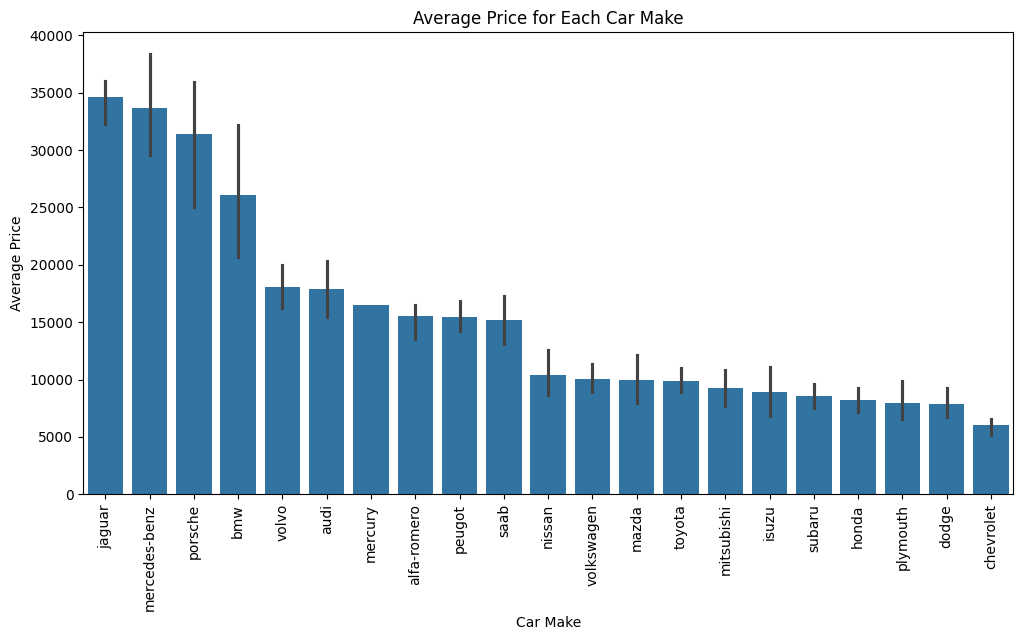

In [8]:
# Locate the 5 most expensive cars in the dataset
most_expensive_cars = automobiles_df.nlargest(5, 'price')
print(most_expensive_cars)

plt.figure(figsize=(12, 6))
sns.barplot(x='make', y='price', data=automobiles_df,
            order=automobiles_df.groupby('make')['price'].mean().sort_values(ascending=False).index)
plt.title('Average Price for Each Car Make')
plt.xlabel('Car Make')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()


#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

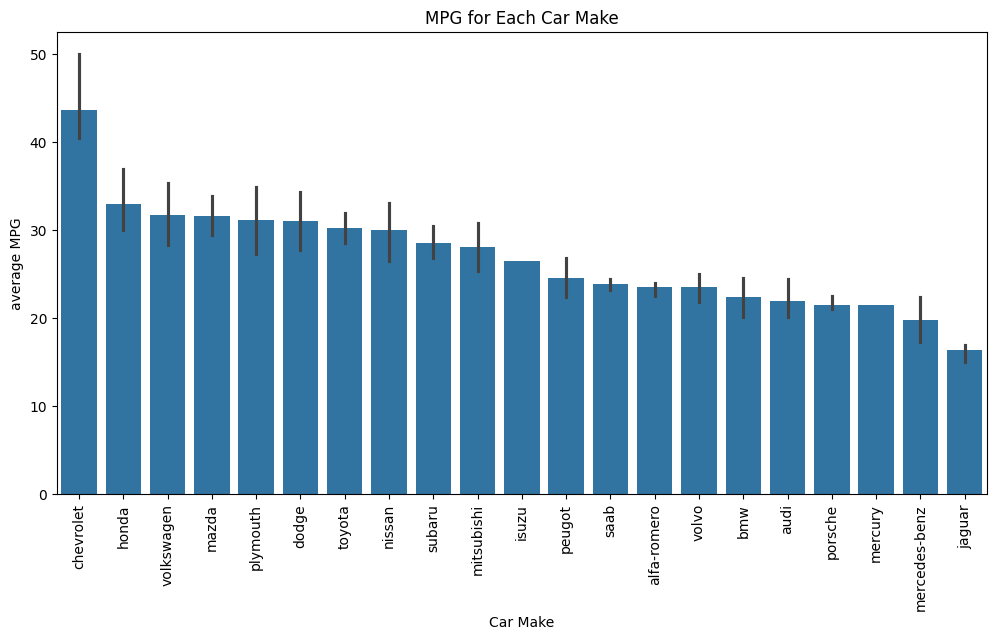

In [9]:
# Bar plot for each car's average mpg
average_mpg = (automobiles_df['city-mpg'] + automobiles_df['highway-mpg']) / 2
automobiles_df['average_mpg'] = average_mpg

plt.figure(figsize=(12, 6))
sns.barplot(x='make', y='average_mpg', data=automobiles_df, 
            order=automobiles_df.groupby('make')['average_mpg'].mean().sort_values(ascending=False).index)
plt.title('MPG for Each Car Make')
plt.xlabel('Car Make')
plt.ylabel('average MPG')
plt.xticks(rotation=90)
plt.show()


<Figure size 1200x600 with 0 Axes>

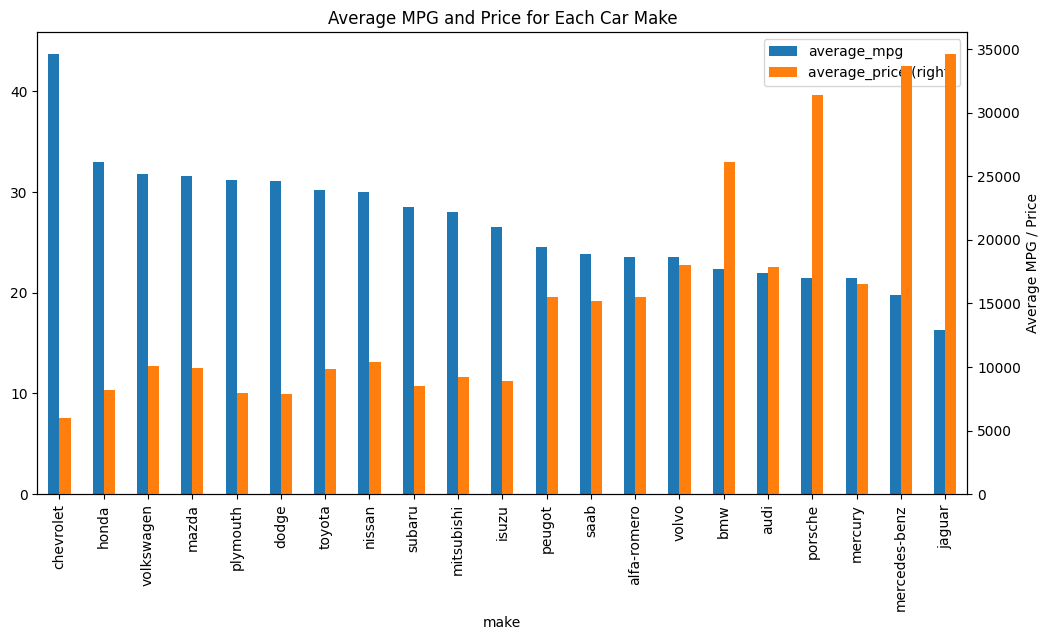

In [10]:
# Compare average MPG and price for each car make

plt.figure(figsize=(12, 6))

automobiles_df['average_mpg'] = average_mpg
automobiles_df['average_price'] = automobiles_df.groupby('make')['price'].transform('mean')

avg_df = automobiles_df.groupby('make')[['average_mpg', 'average_price']].mean().reset_index().sort_values(by='average_price', ascending=False) 

avg_df = automobiles_df.groupby('make')[['average_mpg', 'average_price']].mean().sort_values(by='average_mpg', ascending=False)
avg_df.plot(kind='bar', secondary_y='average_price', figsize=(12, 6))
plt.title('Average MPG and Price for Each Car Make')
plt.xlabel('Car Make')
plt.ylabel('Average MPG / Price')
plt.xticks(rotation=90)
plt.show() 


#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

/var/folders/7j/3xnbl6g97dbchq5zfy5_nh3c0000gn/T/ipykernel_15672/22939968.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='make_index', y='engine-size', data=top20_engines, palette='viridis')


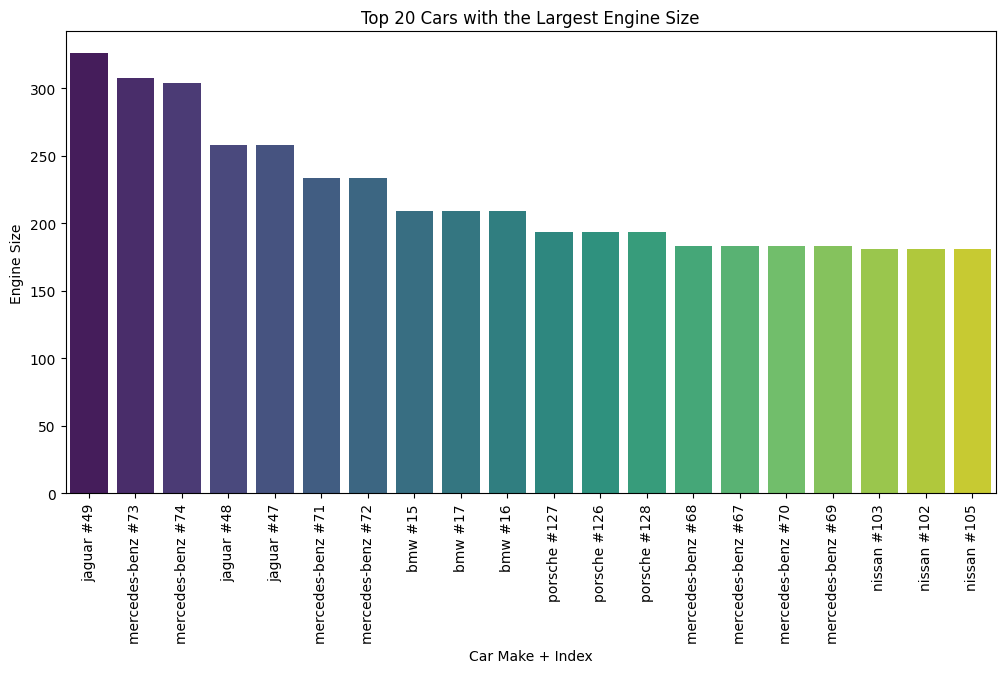

/var/folders/7j/3xnbl6g97dbchq5zfy5_nh3c0000gn/T/ipykernel_15672/22939968.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_engine_size.index, y=average_engine_size.values, palette='magma')


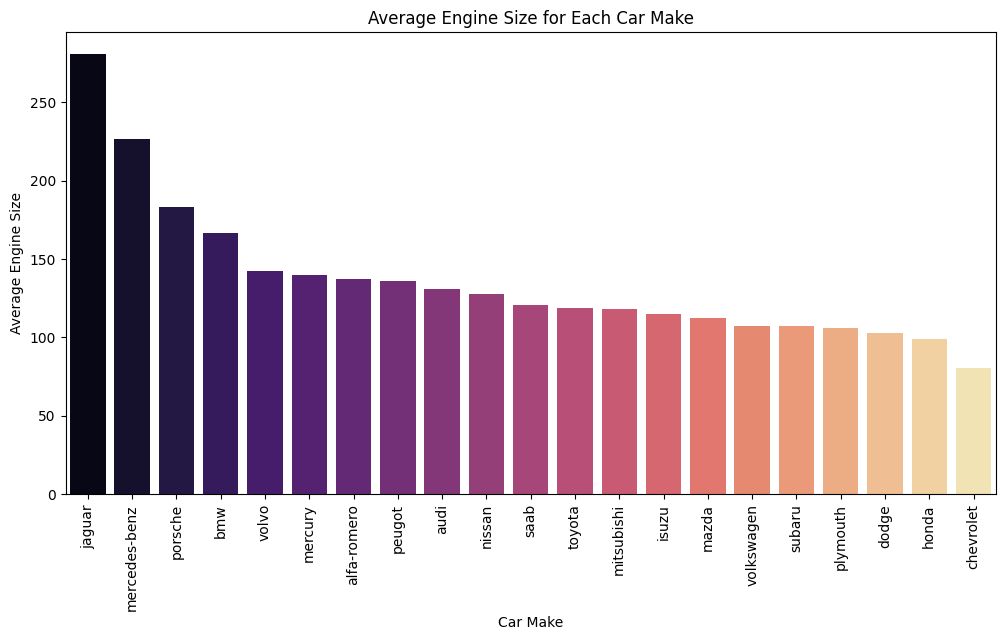

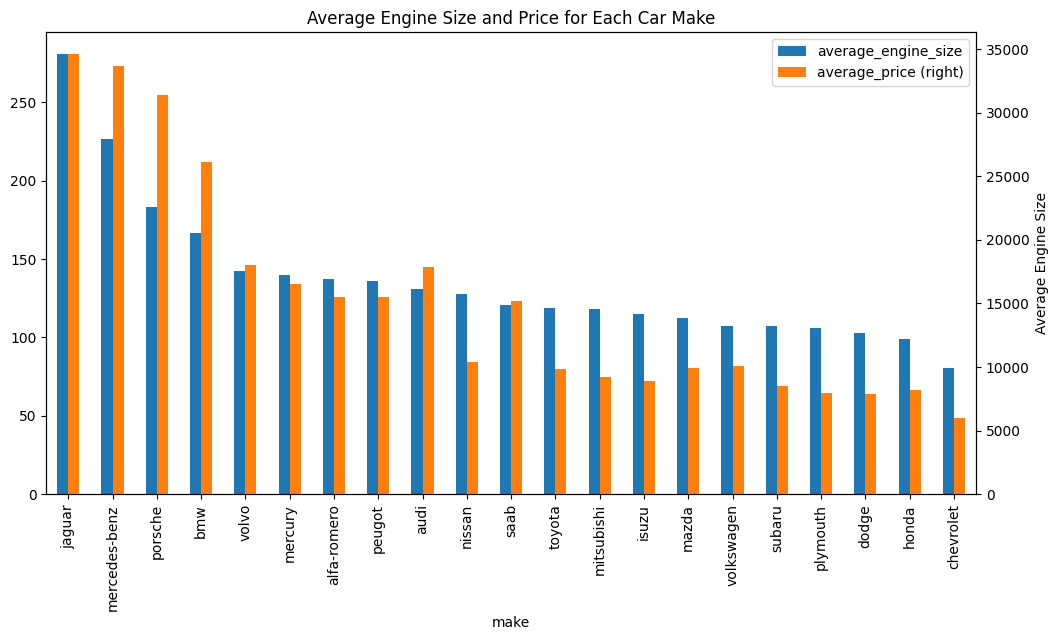

In [11]:
# Display the above on a bar graph

# Create a new column that combines 'make' and 'index' for better visualization
automobiles_df['make_index'] = automobiles_df['make'] + ' ' + '#' + automobiles_df.index.astype(str)

# Sort dataframe based on engine size in descending order
sorted_automobiles = automobiles_df.sort_values(by='engine-size', ascending=False)

# Top 20 cars with the largest engine size
top20_engines = sorted_automobiles.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x='make_index', y='engine-size', data=top20_engines, palette='viridis')
plt.title('Top 20 Cars with the Largest Engine Size')
plt.xlabel('Car Make + Index')
plt.ylabel('Engine Size')
plt.xticks(rotation=90)
plt.show()

# Average engine size for each car make
average_engine_size = automobiles_df.groupby('make')['engine-size'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=average_engine_size.index, y=average_engine_size.values, palette='magma')
plt.title('Average Engine Size for Each Car Make')
plt.xlabel('Car Make')
plt.ylabel('Average Engine Size')
plt.xticks(rotation=90)
plt.show()

# Comparison of average engine size and price for each car make
automobiles_df['average_engine_size'] = automobiles_df.groupby('make')['engine-size'].transform('mean')
automobiles_df['average_price'] = automobiles_df.groupby('make')['price'].transform('mean')

avg_df = automobiles_df.groupby('make')[['average_engine_size', 'average_price']].mean().sort_values(by='average_engine_size', ascending=False)
avg_df.plot(kind='bar', secondary_y='average_price', figsize=(12, 6))
plt.title('Average Engine Size and Price for Each Car Make')
plt.xlabel('Car Make')
plt.ylabel('Average Engine Size')
plt.xticks(rotation=90)
plt.show()



#### Which vehicle manufacturer has the most car models in the dataset

make
toyota           32
nissan           18
honda            13
mazda            13
mitsubishi       13
volkswagen       12
subaru           12
volvo            11
peugot           11
dodge             9
bmw               8
mercedes-benz     8
plymouth          7
saab              6
audi              6
porsche           4
alfa-romero       3
jaguar            3
chevrolet         3
isuzu             2
mercury           1
Name: count, dtype: int64


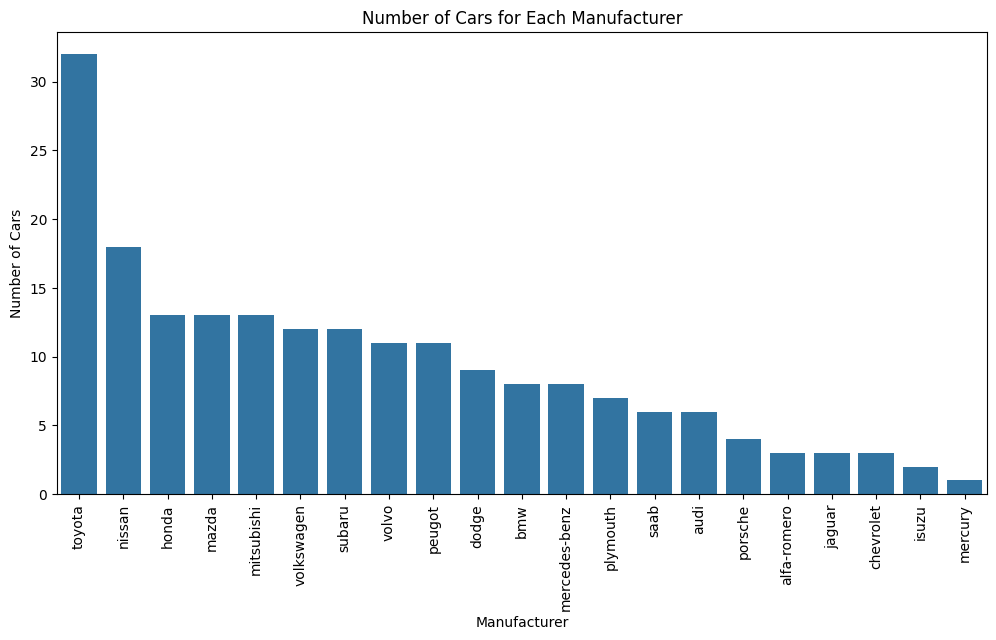

In [12]:
# Count the number of cars for each manufacturer
car_counts = automobiles_df['make'].value_counts()
print(car_counts)

# Display the number of cars for each manufacturer in a bar graph
plt.figure(figsize=(12, 6))
sns.barplot(x=car_counts.index, y=car_counts.values)
plt.title('Number of Cars for Each Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Cars')
plt.xticks(rotation=90)
plt.show()


